**PERCOBAAN 1**

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [3]:
data = {
    'Bulan': ['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember'],
    'Curah_Hujan': [840, 1, 397, 626, 294, 78, 87, 77, 104, 83, 245, 542],
    'Hari_Hujan': [20, 20, 23, 11, 11, 14, 9, 8, 11, 17, 26, 28]
}

df = pd.DataFrame(data)

In [4]:
def kategorikan_hari(hari):
    if hari <= 10:
        return 'Rendah'
    elif hari <= 20:
        return 'Sedang'
    else:
        return 'Tinggi'

df['Kategori_Hari_Hujan'] = df['Hari_Hujan'].apply(kategorikan_hari)


In [5]:
X = df[['Curah_Hujan']]
y = df['Kategori_Hari_Hujan']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

In [6]:


print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))


curah_hujan_baru = pd.DataFrame({'Curah_Hujan': [300]})
prediksi = model.predict(curah_hujan_baru)
print(f"\nPrediksi kategori hari hujan untuk curah hujan 300 mm: {prediksi[0]}")


Akurasi: 0.3333333333333333

Laporan Klasifikasi:
              precision    recall  f1-score   support

      Rendah       0.00      0.00      0.00         0
      Sedang       0.50      0.50      0.50         2
      Tinggi       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.17      0.17      0.17         3
weighted avg       0.33      0.33      0.33         3


Prediksi kategori hari hujan untuk curah hujan 300 mm: Sedang


**  Percobaan 2 **



In [7]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
data = {
    'Bulan': ['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni',
              'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember'],
    'Curah_Hujan': [840, 1, 397, 626, 294, 78, 87, 77, 104, 245, 542, 860],
    'Hari_Hujan': [20, 20, 23, 11, 11, 14, 9, 8, 11, 17, 26, 28]
}

df = pd.DataFrame(data)
df['Bulan_Num'] = df.index + 1

In [9]:
df['Kuartal'] = df['Bulan_Num'].apply(lambda x: (x - 1) // 3 + 1)

In [10]:
def musim(bulan):
    if bulan in [12, 1, 2]:
        return 'Musim Hujan'
    elif bulan in [3, 4, 5]:
        return 'Peralihan 1'
    elif bulan in [6, 7, 8]:
        return 'Musim Kemarau'
    else:
        return 'Peralihan 2'

df['Musim'] = df['Bulan_Num'].apply(musim)

In [11]:
df = pd.get_dummies(df, columns=['Musim'])

In [12]:
df['sin_bulan'] = np.sin(2 * np.pi * df['Bulan_Num'] / 12)
df['cos_bulan'] = np.cos(2 * np.pi * df['Bulan_Num'] / 12)


In [13]:
def klasifikasi_hari(hari):
    if hari <= 10:
        return 'Rendah'
    elif hari <= 20:
        return 'Sedang'
    else:
        return 'Tinggi'

df['Label'] = df['Hari_Hujan'].apply(klasifikasi_hari)

In [14]:
features = ['Curah_Hujan', 'Kuartal', 'sin_bulan', 'cos_bulan'] + [col for col in df.columns if col.startswith('Musim_')]
X = df[features]
y = df['Label']

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_scaled, y, cv=cv)

print(f"Akurasi rata-rata cross-validation: {scores.mean():.2f}")
print(f"Akurasi tiap fold: {scores}")

Akurasi rata-rata cross-validation: 0.40
Akurasi tiap fold: [0.33333333 0.66666667 0.         0.5        0.5       ]


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, stratify=y, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Akurasi Test:", accuracy_score(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

      Rendah       0.00      0.00      0.00         0
      Sedang       0.50      0.50      0.50         2
      Tinggi       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.17      0.17      0.17         3
weighted avg       0.33      0.33      0.33         3

Akurasi Test: 0.3333333333333333


In [18]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:


data = [

    ['Januari', 1, 2020, 381, 16],
    ['Februari', 2, 2020, 558, 23],
    ['Maret', 3, 2020, 345, 14],
    ['April', 4, 2020, 150, 13],
    ['Mei', 5, 2020, 81, 7],
    ['Juni', 6, 2020, 137, 4],
    ['Juli', 7, 2020, 25, 3],
    ['Agustus', 8, 2020, 17, 1],
    ['September', 9, 2020, 22, 3],
    ['Oktober', 10, 2020, 136, 11],
    ['November', 11, 2020, 204, 14],
    ['Desember', 12, 2020, 387, 21],


    ['Januari', 1, 2021, 840, 30],
    ['Februari', 2, 2021, 397, 20],
    ['Maret', 3, 2021, 626, 23],
    ['April', 4, 2021, 294, 11],
    ['Mei', 5, 2021, 78, 11],
    ['Juni', 6, 2021, 87, 14],
    ['Juli', 7, 2021, 77, 9],
    ['Agustus', 8, 2021, 104, 8],
    ['September', 9, 2021, 83, 11],
    ['Oktober', 10, 2021, 245, 17],
    ['November', 11, 2021, 542, 26],
    ['Desember', 12, 2021, 860, 28],


    ['Januari', 1, 2022, 840, 30],
    ['Februari', 2, 2022, 397, 20],
    ['Maret', 3, 2022, 626, 23],
    ['April', 4, 2022, 294, 11],
    ['Mei', 5, 2022, 78, 11],
    ['Juni', 6, 2022, 87, 14],
    ['Juli', 7, 2022, 77, 9],
    ['Agustus', 8, 2022, 104, 8],
    ['September', 9, 2022, 83, 11],
    ['Oktober', 10, 2022, 245, 17],
    ['November', 11, 2022, 542, 26],
    ['Desember', 12, 2022, 860, 28],
]


df = pd.DataFrame(data, columns=['Bulan', 'Bulan_Num', 'Tahun', 'Curah_Hujan', 'Hari_Hujan'])


In [20]:

def klasifikasi(hari):
    if hari <= 10:
        return 'Rendah'
    elif hari <= 20:
        return 'Sedang'
    else:
        return 'Tinggi'
df['Label'] = df['Hari_Hujan'].apply(klasifikasi)

df['Kuartal'] = df['Bulan_Num'].apply(lambda x: (x - 1) // 3 + 1)
df['sin_bulan'] = np.sin(2 * np.pi * df['Bulan_Num'] / 12)
df['cos_bulan'] = np.cos(2 * np.pi * df['Bulan_Num'] / 12)


In [21]:

def musim(b):
    if b in [12, 1, 2]: return 'Hujan'
    elif b in [3, 4, 5]: return 'Peralihan1'
    elif b in [6, 7, 8]: return 'Kemarau'
    else: return 'Peralihan2'
df['Musim'] = df['Bulan_Num'].apply(musim)
df = pd.get_dummies(df, columns=['Musim'])


In [22]:

features = ['Curah_Hujan', 'Bulan_Num', 'Tahun', 'Kuartal', 'sin_bulan', 'cos_bulan'] + [col for col in df.columns if col.startswith('Musim_')]
X = df[features]
y = df['Label']


X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Akurasi: 0.8888888888888888

Classification Report:
               precision    recall  f1-score   support

      Rendah       1.00      0.50      0.67         2
      Sedang       0.80      1.00      0.89         4
      Tinggi       1.00      1.00      1.00         3

    accuracy                           0.89         9
   macro avg       0.93      0.83      0.85         9
weighted avg       0.91      0.89      0.88         9




Cross-Validation Accuracy: 0.78
Setiap Fold: [0.75       0.85714286 1.         0.57142857 0.71428571]


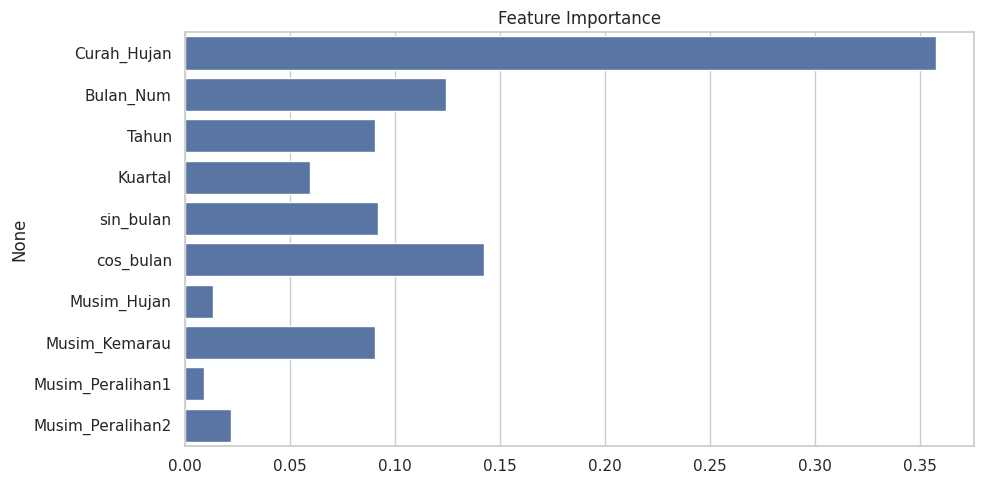

In [23]:


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv)
print(f"\nCross-Validation Accuracy: {scores.mean():.2f}")
print("Setiap Fold:", scores)


plt.figure(figsize=(10, 5))
sns.barplot(x=model.feature_importances_, y=X.columns)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()


In [24]:
import matplotlib.ticker as mtick
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

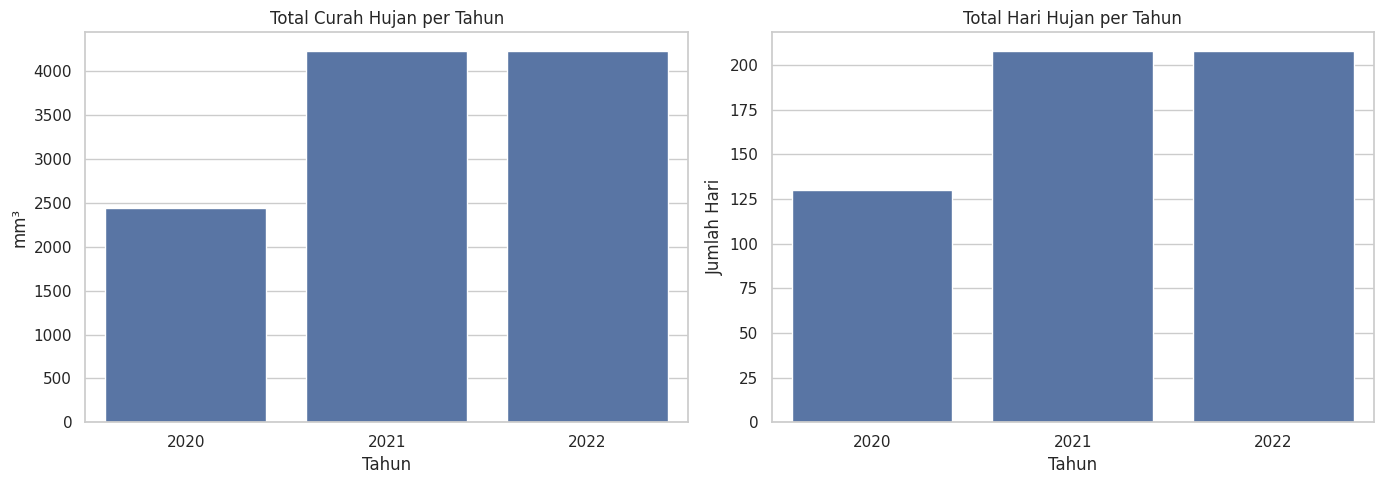

In [25]:

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x='Tahun', y='Curah_Hujan', ci=None, estimator=sum, ax=axs[0])
axs[0].set_title('Total Curah Hujan per Tahun')
axs[0].set_ylabel('mm³')

sns.barplot(data=df, x='Tahun', y='Hari_Hujan', ci=None, estimator=sum, ax=axs[1])
axs[1].set_title('Total Hari Hujan per Tahun')
axs[1].set_ylabel('Jumlah Hari')

plt.tight_layout()
plt.show()

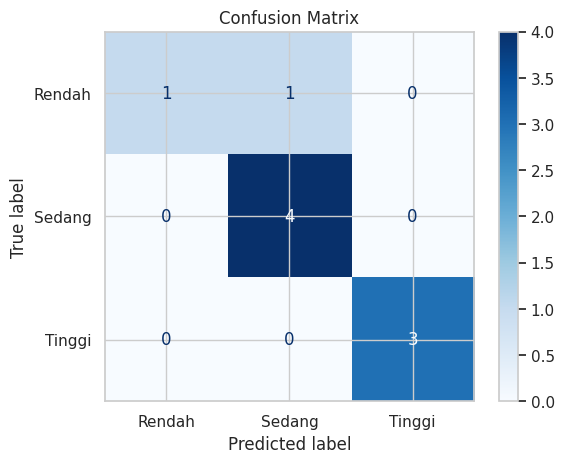

In [26]:


cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


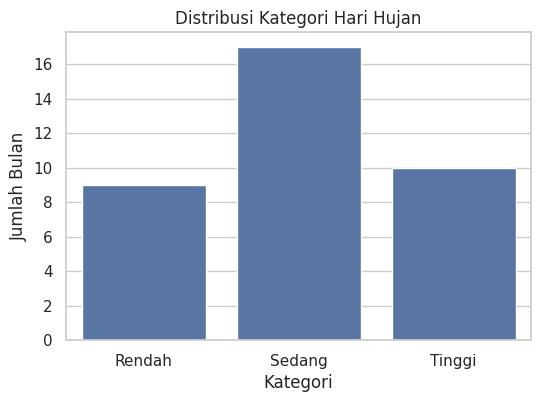

In [27]:



plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Label', order=['Rendah', 'Sedang', 'Tinggi'])
plt.title('Distribusi Kategori Hari Hujan')
plt.ylabel('Jumlah Bulan')
plt.xlabel('Kategori')
plt.show()



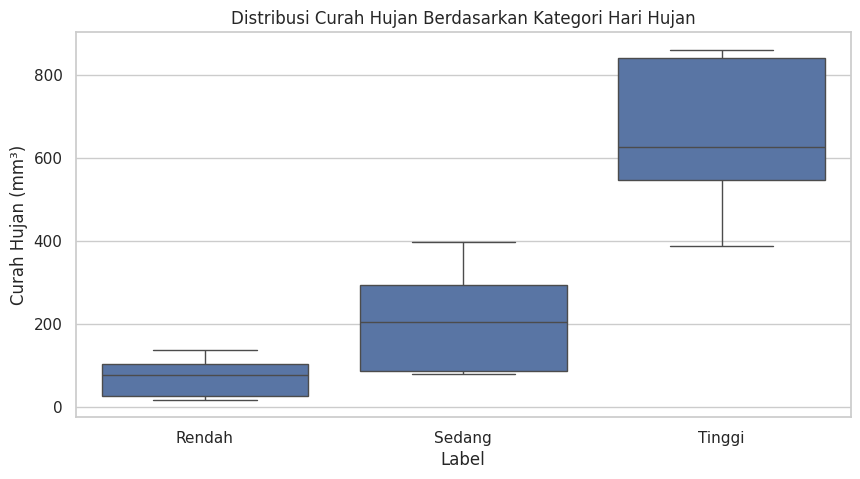

In [28]:


plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Label', y='Curah_Hujan', order=['Rendah', 'Sedang', 'Tinggi'])
plt.title('Distribusi Curah Hujan Berdasarkan Kategori Hari Hujan')
plt.ylabel('Curah Hujan (mm³)')
plt.xlabel('Label')
plt.show()


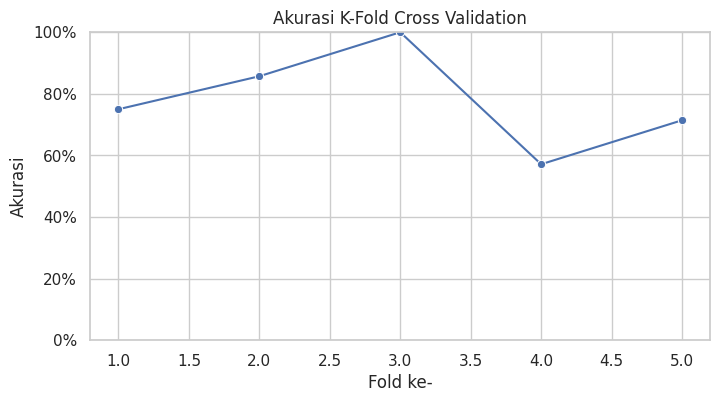

In [29]:


plt.figure(figsize=(8, 4))
sns.lineplot(x=list(range(1, len(scores)+1)), y=scores, marker='o')
plt.title('Akurasi K-Fold Cross Validation')
plt.xlabel('Fold ke-')
plt.ylabel('Akurasi')
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(True)
plt.show()


Percobaan ketiga

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [31]:
data = [
    ['Januari', 1, 2020, 381, 16],
    ['Februari', 2, 2020, 558, 23],
    ['Maret', 3, 2020, 345, 14],
    ['April', 4, 2020, 150, 13],
    ['Mei', 5, 2020, 81, 7],
    ['Juni', 6, 2020, 137, 4],
    ['Juli', 7, 2020, 25, 3],
    ['Agustus', 8, 2020, 17, 1],
    ['September', 9, 2020, 22, 3],
    ['Oktober', 10, 2020, 136, 11],
    ['November', 11, 2020, 204, 14],
    ['Desember', 12, 2020, 387, 21],
    ['Januari', 1, 2021, 840, 30],
    ['Februari', 2, 2021, 397, 20],
    ['Maret', 3, 2021, 626, 23],
    ['April', 4, 2021, 294, 11],
    ['Mei', 5, 2021, 78, 11],
    ['Juni', 6, 2021, 87, 14],
    ['Juli', 7, 2021, 77, 9],
    ['Agustus', 8, 2021, 104, 8],
    ['September', 9, 2021, 83, 11],
    ['Oktober', 10, 2021, 245, 17],
    ['November', 11, 2021, 542, 26],
    ['Desember', 12, 2021, 860, 28],
    ['Januari', 1, 2022, 840, 30],
    ['Februari', 2, 2022, 397, 20],
    ['Maret', 3, 2022, 626, 23],
    ['April', 4, 2022, 294, 11],
    ['Mei', 5, 2022, 78, 11],
    ['Juni', 6, 2022, 87, 14],
    ['Juli', 7, 2022, 77, 9],
    ['Agustus', 8, 2022, 104, 8],
    ['September', 9, 2022, 83, 11],
    ['Oktober', 10, 2022, 245, 17],
    ['November', 11, 2022, 542, 26],
    ['Desember', 12, 2022, 860, 28],
]
df = pd.DataFrame(data, columns=['Bulan', 'Bulan_Num', 'Tahun', 'Curah_Hujan', 'Hari_Hujan'])

In [32]:
def klasifikasi(hari):
    if hari <= 10: return 'Rendah'
    elif hari <= 20: return 'Sedang'
    else: return 'Tinggi'
df['Label'] = df['Hari_Hujan'].apply(klasifikasi)

In [33]:
df['Kuartal'] = df['Bulan_Num'].apply(lambda x: (x-1)//3 + 1)
df['Curah_per_Hari'] = df['Curah_Hujan'] / df['Hari_Hujan']
df['sin_bulan'] = np.sin(2 * np.pi * df['Bulan_Num'] / 12)
df['cos_bulan'] = np.cos(2 * np.pi * df['Bulan_Num'] / 12)

def musim(b):
    if b in [12, 1, 2]: return 'Hujan'
    elif b in [3, 4, 5]: return 'Peralihan1'
    elif b in [6, 7, 8]: return 'Kemarau'
    else: return 'Peralihan2'
df['Musim'] = df['Bulan_Num'].apply(musim)
df = pd.get_dummies(df, columns=['Musim'])

In [34]:
X = df[['Curah_Hujan', 'Hari_Hujan', 'Curah_per_Hari', 'Bulan_Num', 'Tahun', 'Kuartal', 'sin_bulan', 'cos_bulan'] + [col for col in df.columns if col.startswith('Musim_')]]
y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)


In [35]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
}
rf = RandomForestClassifier(random_state=42)
grid = GridSearchCV(rf, param_grid, cv=5)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

Best Parameters: {'max_depth': 5, 'n_estimators': 200}
Akurasi: 1.0
              precision    recall  f1-score   support

      Rendah       1.00      1.00      1.00         2
      Sedang       1.00      1.00      1.00         4
      Tinggi       1.00      1.00      1.00         3

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9

Cross-Validation Akurasi:  0.9464285714285715
Semua Fold: [0.875      0.85714286 1.         1.         1.        ]


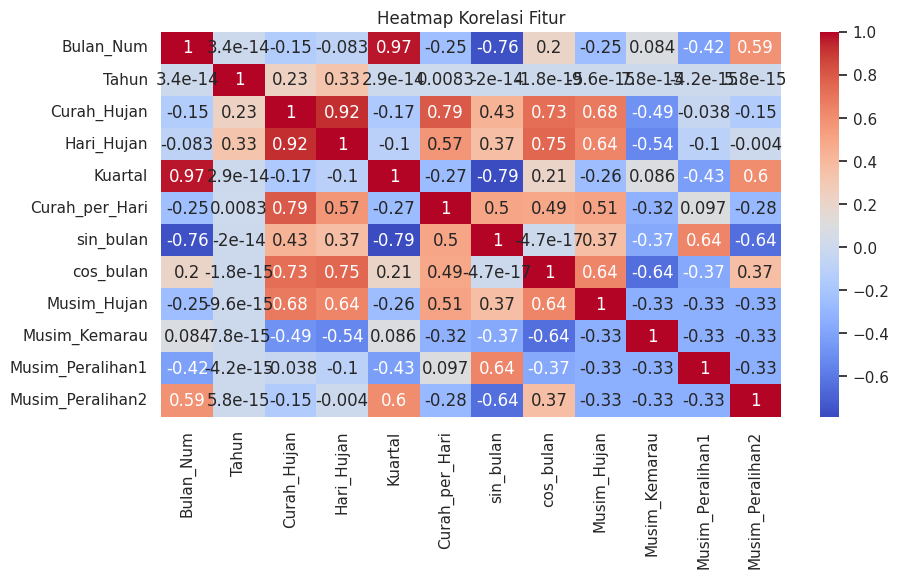

In [36]:
print("Best Parameters:", grid.best_params_)
print("Akurasi:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X, y, cv=cv)
print("Cross-Validation Akurasi: ", cv_scores.mean())
print("Semua Fold:", cv_scores)

sns.set(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Heatmap Korelasi Fitur")
plt.show()

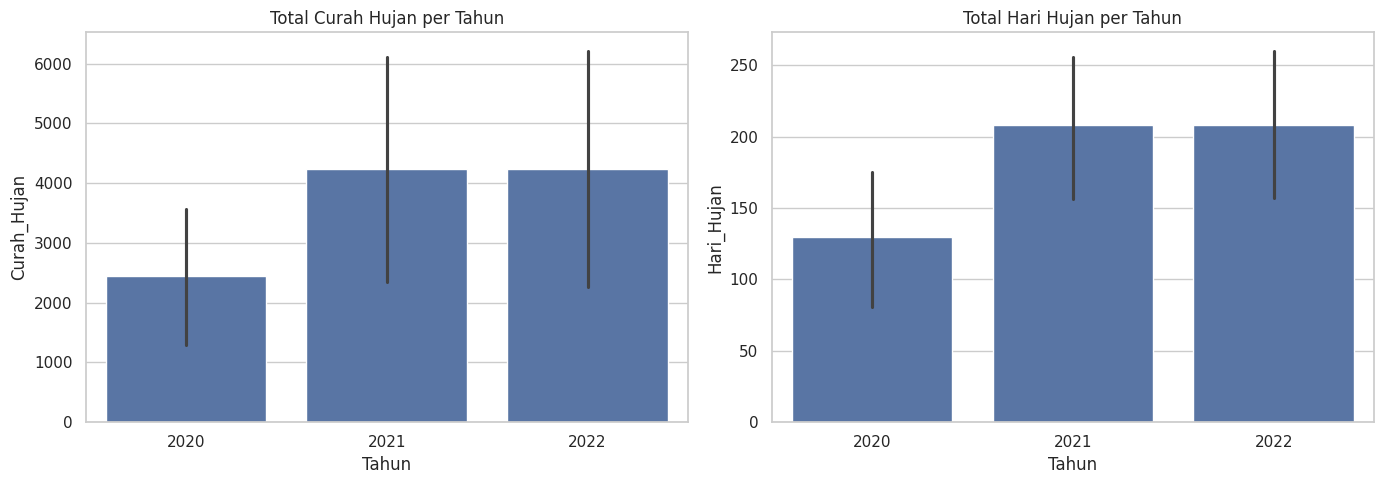

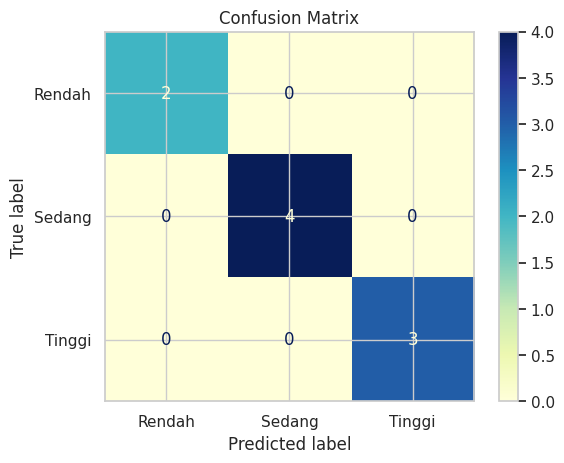

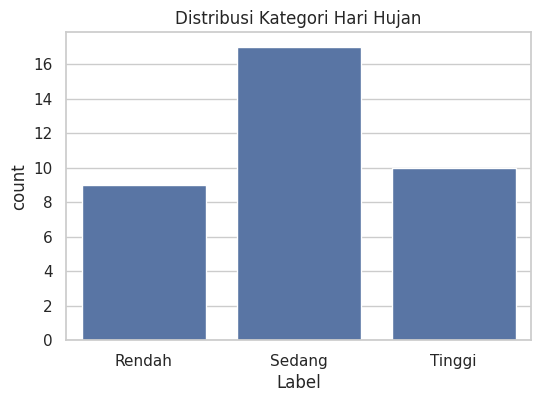

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df, x='Tahun', y='Curah_Hujan', estimator=sum, ax=ax[0])
ax[0].set_title("Total Curah Hujan per Tahun")
sns.barplot(data=df, x='Tahun', y='Hari_Hujan', estimator=sum, ax=ax[1])
ax[1].set_title("Total Hari Hujan per Tahun")
plt.tight_layout()
plt.show()


cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap="YlGnBu")
plt.title("Confusion Matrix")
plt.show()


plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Label', order=['Rendah', 'Sedang', 'Tinggi'])
plt.title("Distribusi Kategori Hari Hujan")
plt.show()


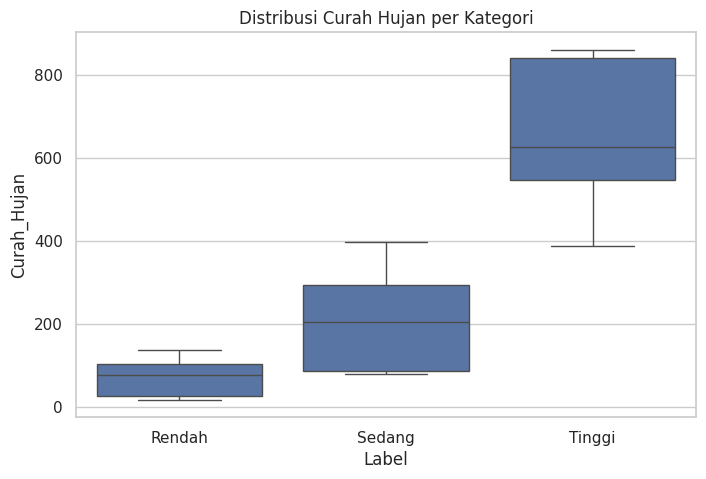

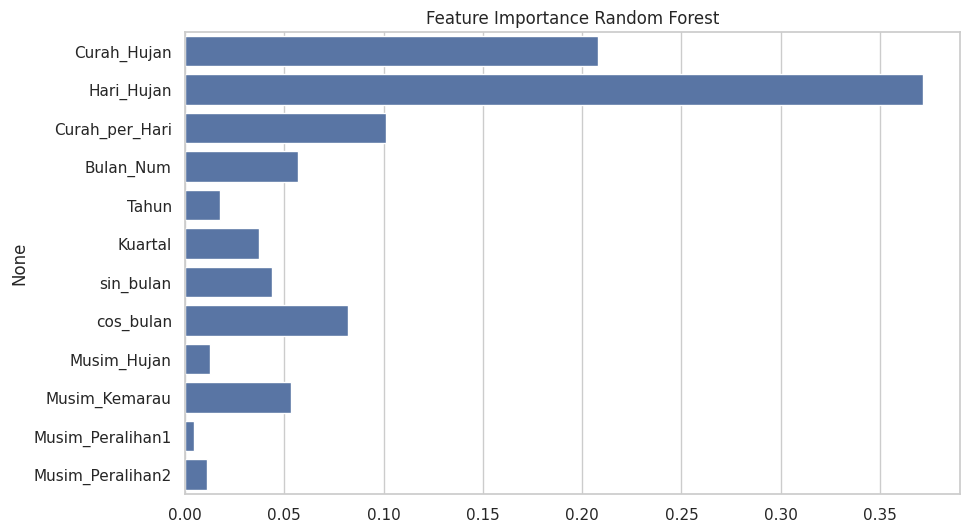

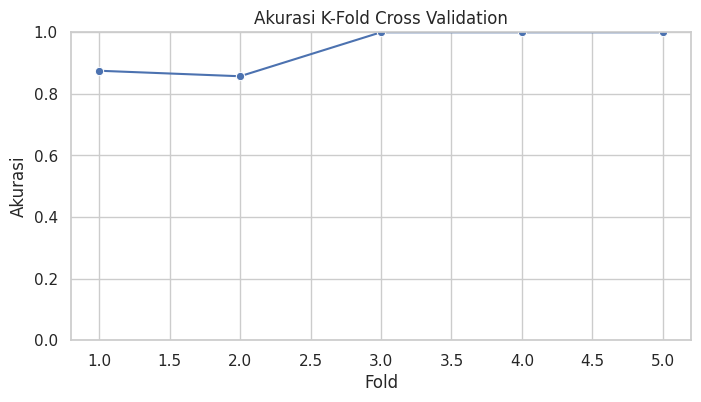

In [38]:




plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Label', y='Curah_Hujan', order=['Rendah', 'Sedang', 'Tinggi'])
plt.title("Distribusi Curah Hujan per Kategori")
plt.show()


plt.figure(figsize=(10, 6))
sns.barplot(x=best_model.feature_importances_, y=X.columns)
plt.title("Feature Importance Random Forest")
plt.show()


plt.figure(figsize=(8,4))
sns.lineplot(x=range(1, 6), y=cv_scores, marker='o')
plt.ylim(0, 1)
plt.title("Akurasi K-Fold Cross Validation")
plt.xlabel("Fold")
plt.ylabel("Akurasi")
plt.grid(True)
plt.show()
